# Spatial Coverage Assessment

**Question**: Does the station network provide sufficient geographic coverage for differentiated emergency decisions — and for whom does it fail?

This notebook:
1. Maps all Radnett stations color-coded by operational reliability
2. Computes coverage buffers around operative stations
3. Identifies geographic gaps
4. Assesses whether Civil Defence patrols fill those gaps or overlap
5. Discovers additional coordinate errors through spatial analysis

---

## Setup

In [4]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from src.data_loader import load_radnett, load_station_locations, load_civil_defence
from src.utils import (
    save_figure, classify_uptime, haversine_km,
    STATION_TYPE_COLORS, UPTIME_COLORS
)

## 1. Prepare station data with uptime and placement

In [5]:
radnett = load_radnett()
stations = load_station_locations()
civil = load_civil_defence()

# Compute uptime per station
uptime = radnett.groupby("station_name").apply(
    lambda g: (g["dose_rate_microsv_h"] > 0).mean()
)

# Load placement from DSA report (skip comment header lines)
report = pd.read_csv(
    PROJECT_ROOT / "data" / "reference" / "dsa_report_table1_radnett.csv",
    comment="#",
)
placement_map = dict(zip(report["station_name"], report["placement"]))

# Enrich station data
stations["uptime"] = stations["station_name"].map(uptime)
stations["uptime_class"] = stations["uptime"].apply(classify_uptime)
stations["placement"] = stations["station_name"].map(placement_map)
stations["station_type"] = stations["station_name"].apply(
    lambda n: "air_filter" if "(Luftfilter)" in n else ("mobile" if "Mobil" in n else "fixed")
)

# Separate real stations from mobile placeholders
real_stations = stations[~stations["station_name"].str.contains("Mobil")].copy()
operative = real_stations[real_stations["uptime"] > 0.50].copy()

print(f"Total stations in data: {len(stations)}")
print(f"Real (non-mobile): {len(real_stations)}")
print(f"Operative (>50% uptime): {len(operative)}")
print(f"\nBy uptime class:")
print(real_stations["uptime_class"].value_counts())

Total stations in data: 44
Real (non-mobile): 38
Operative (>50% uptime): 31

By uptime class:
uptime_class
reliable    24
offline      7
unstable     7
Name: count, dtype: int64


## 2. Station map — colored by operational reliability

Each station is colored by its actual uptime in 2023, not its design status. Coverage circles (~100 km radius) show the approximate area each operative station covers. Square markers indicate building-mounted stations.

In [17]:
# Load Natural Earth land polygons for coastline/land context
try:
    import geodatasets
    land = gpd.read_file(geodatasets.get_path("naturalearth.land"))
    mainland_land = land.clip_by_rect(3, 55, 35, 72)
    svalbard_land = land.clip_by_rect(10, 74, 30, 82)
    has_boundaries = True
    print("Natural Earth land polygons loaded")
except Exception as e:
    has_boundaries = False
    mainland_land = None
    svalbard_land = None
    print(f"No basemap available ({e}) — plotting stations only")

Natural Earth land polygons loaded


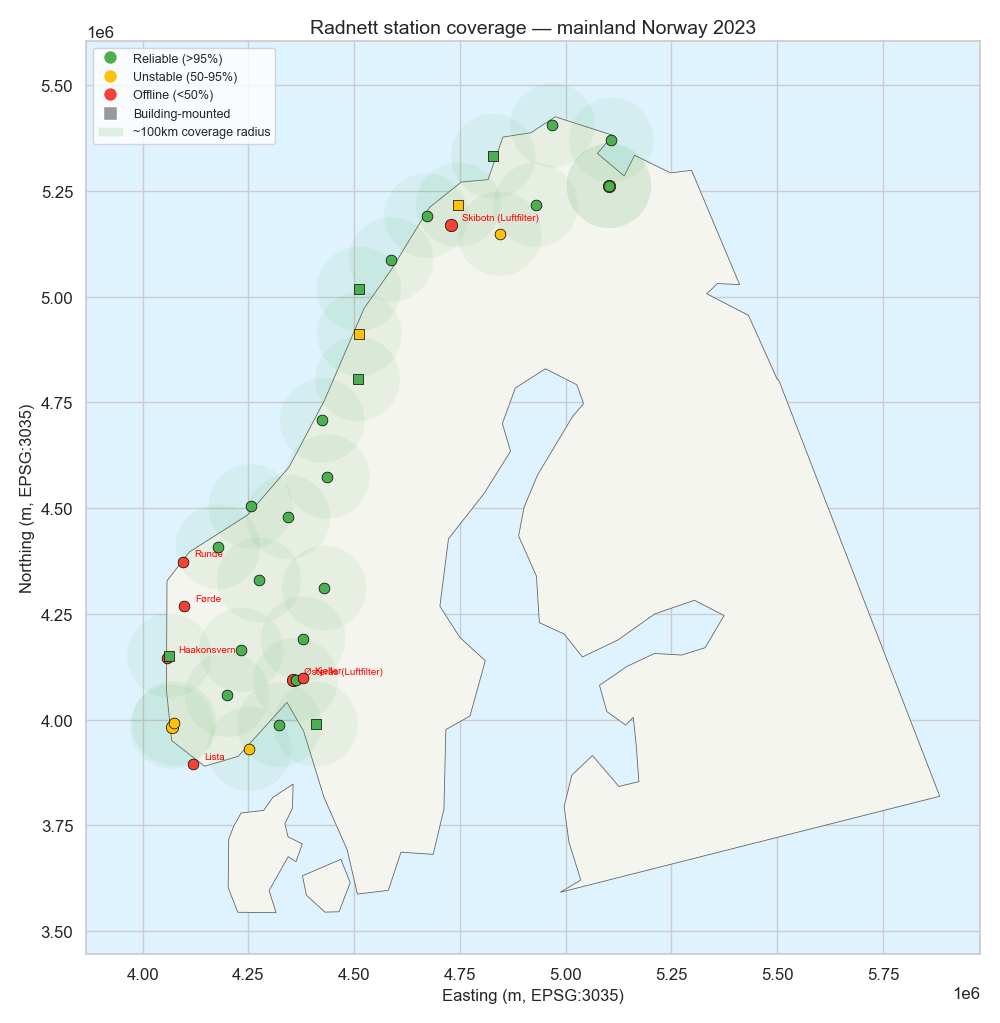

In [25]:
# Build mainland map in projected CRS to keep 100 km buffers visually circular everywhere
plot_crs = 3035

# Keep mainland panel clean: exclude Svalbard (handled in separate inset)
mainland_stations = real_stations[real_stations["latitude"] <= 73].copy()
mainland_operative = operative[operative["latitude"] <= 73].copy()

stations_proj = mainland_stations.to_crs(epsg=plot_crs)
operative_proj = mainland_operative.to_crs(epsg=plot_crs)
coverage_buffers = operative_proj.copy()
coverage_buffers["geometry"] = operative_proj.geometry.buffer(100_000)  # meters

fig, ax = plt.subplots(figsize=(10, 16))
ax.set_facecolor("#dff3ff")  # ocean background

# Draw land/coastline context if available
if has_boundaries:
    mainland_land_proj = gpd.GeoSeries(mainland_land, crs=4326).to_crs(epsg=plot_crs)
    mainland_land_proj.plot(ax=ax, color="#f5f5f0", edgecolor="#666666", linewidth=0.6, zorder=1)

# Coverage buffers for operative stations (~100 km), true circles in projected CRS
coverage_buffers.plot(ax=ax, color="#4CAF50", alpha=0.08, linewidth=0, zorder=2)

# Plot stations
for _, row in stations_proj.iterrows():
    color = UPTIME_COLORS.get(row["uptime_class"], "#999")
    marker = "s" if row.get("placement") == "building" else "o"
    size = 80 if row["station_type"] == "air_filter" else 60
    ax.scatter(
        row.geometry.x, row.geometry.y,
        c=color, s=size, marker=marker, edgecolors="black", linewidth=0.5, zorder=5
    )

# Label offline stations
offline = stations_proj[stations_proj["uptime_class"] == "offline"]
for _, row in offline.iterrows():
    ax.annotate(
        row["station_name"], (row.geometry.x, row.geometry.y),
        textcoords="offset points", xytext=(8, 4), fontsize=7, color="red"
    )

# Legend
legend_elements = [
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#4CAF50", markersize=10, label="Reliable (>95%)"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#FFC107", markersize=10, label="Unstable (50-95%)"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#F44336", markersize=10, label="Offline (<50%)"),
    Line2D([0],[0], marker="s", color="w", markerfacecolor="#999", markersize=10, label="Building-mounted"),
    Patch(facecolor="#4CAF50", alpha=0.15, label="~100km coverage radius"),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=9)

ax.set_xlabel("Easting (m, EPSG:3035)")
ax.set_ylabel("Northing (m, EPSG:3035)")
ax.set_title("Radnett station coverage — mainland Norway 2023")
ax.set_aspect("equal")

plt.tight_layout()
save_figure(fig, "station_coverage_mainland")
plt.show()

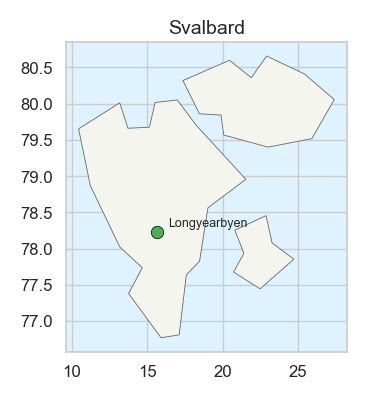

In [19]:
# Svalbard inset
svalbard = real_stations[real_stations["latitude"] > 74]
if len(svalbard) > 0:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.set_facecolor("#dff3ff")
    if has_boundaries:
        svalbard_land.plot(ax=ax, color="#f5f5f0", edgecolor="#666666", linewidth=0.6, zorder=1)
    for _, row in svalbard.iterrows():
        color = UPTIME_COLORS.get(row["uptime_class"], "#999")
        ax.scatter(row["longitude"], row["latitude"], c=color, s=80,
                   edgecolors="black", linewidth=0.5, zorder=5)
        ax.annotate(row["station_name"], (row["longitude"], row["latitude"]),
                    textcoords="offset points", xytext=(8, 4), fontsize=9)
    ax.set_title("Svalbard")
    ax.set_aspect(1 / np.cos(np.radians(78)))
    plt.tight_layout()
    save_figure(fig, "station_coverage_svalbard")
    plt.show()

## 3. Civil Defence measurement coverage

Do the Civil Defence patrols fill Radnett gaps, or do they measure in the same places?

In [9]:
# Filter Civil Defence to valid mainland coordinates
civil_valid = civil[
    (civil["latitude"] > 55) & (civil["latitude"] < 73) &
    (civil["longitude"] > 3) & (civil["longitude"] < 33)
].copy()

print(f"Civil Defence: {len(civil)} total, {len(civil_valid)} with valid mainland coordinates")
print(f"Excluded: {len(civil) - len(civil_valid)} (zero coords, corrupt coords, Svalbard)")

Civil Defence: 2356 total, 2343 with valid mainland coordinates
Excluded: 13 (zero coords, corrupt coords, Svalbard)


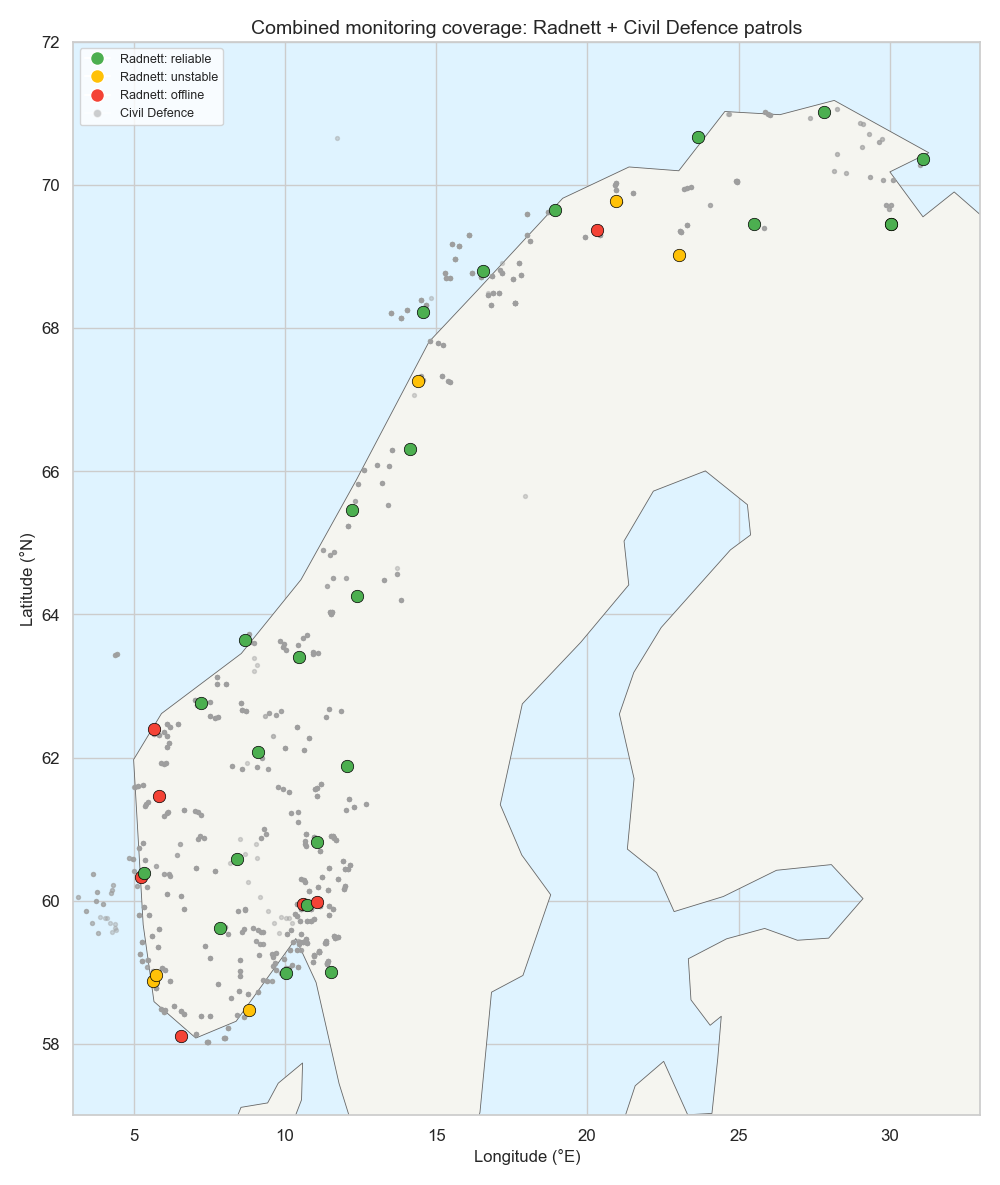

In [20]:
# Combined map: Radnett + Civil Defence
fig, ax = plt.subplots(figsize=(10, 16))
ax.set_facecolor("#dff3ff")

if has_boundaries:
    mainland_land.plot(ax=ax, color="#f5f5f0", edgecolor="#666666", linewidth=0.6, zorder=1)

# Civil Defence points (small, grey, background)
ax.scatter(
    civil_valid["longitude"], civil_valid["latitude"],
    c="#9E9E9E", s=8, alpha=0.4, zorder=3,
    label=f"Civil Defence (n={len(civil_valid)})"
)

# Radnett stations (larger, colored by uptime)
for _, row in real_stations.iterrows():
    if row["latitude"] > 73: continue  # skip Svalbard for this plot
    color = UPTIME_COLORS.get(row["uptime_class"], "#999")
    ax.scatter(row["longitude"], row["latitude"],
              c=color, s=80, edgecolors="black", linewidth=0.5, zorder=5)

legend_elements = [
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#4CAF50", markersize=10, label="Radnett: reliable"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#FFC107", markersize=10, label="Radnett: unstable"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#F44336", markersize=10, label="Radnett: offline"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#9E9E9E", markersize=6, alpha=0.5, label="Civil Defence"),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=9)
ax.set_xlim(3, 33)
ax.set_ylim(57, 72)
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_title("Combined monitoring coverage: Radnett + Civil Defence patrols")
ax.set_aspect(1 / np.cos(np.radians(65)))

plt.tight_layout()
save_figure(fig, "combined_coverage_map")
plt.show()

## 4. Distance analysis

For each Civil Defence measurement, how far is the nearest operative Radnett station? This tells us whether the two systems are complementary (patrols fill gaps) or redundant (measuring the same areas).

In [11]:
# Use EPSG:3035 (LAEA Europe) for distance — covers all of Norway correctly
# Note: UTM zone 33 distorts eastern Finnmark (Hammerfest at lon 23°)
operative_proj = operative.to_crs(epsg=3035)
civil_proj = civil_valid.to_crs(epsg=3035)

# Nearest spatial join
joined = gpd.sjoin_nearest(civil_proj, operative_proj, how="left", distance_col="distance_m")
joined["distance_km"] = joined["distance_m"] / 1000

print("Distance from each Civil Defence point to nearest OPERATIVE Radnett station:")
print(f"  Median:      {joined['distance_km'].median():.1f} km")
print(f"  Mean:        {joined['distance_km'].mean():.1f} km")
print(f"  Max:         {joined['distance_km'].max():.1f} km")
print(f"  Within 50km:  {(joined['distance_km'] < 50).mean()*100:.1f}%")
print(f"  Within 100km: {(joined['distance_km'] < 100).mean()*100:.1f}%")
print(f"  Beyond 150km: {(joined['distance_km'] > 150).sum()} points")

Distance from each Civil Defence point to nearest OPERATIVE Radnett station:
  Median:      45.9 km
  Mean:        46.6 km
  Max:         279.2 km
  Within 50km:  56.3%
  Within 100km: 95.1%
  Beyond 150km: 10 points


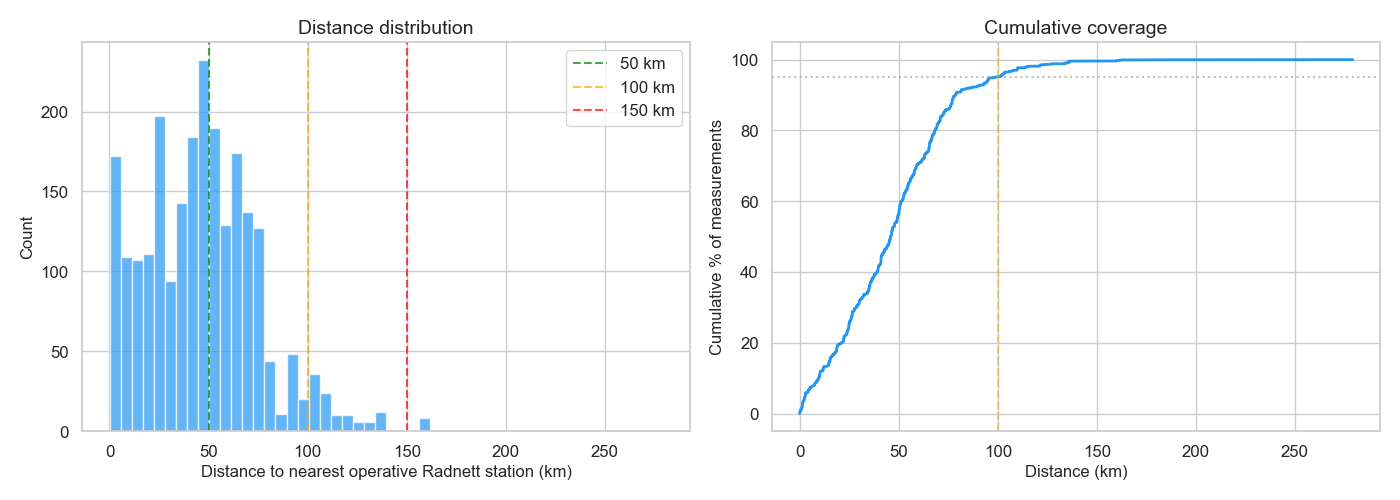

In [12]:
# Distance distribution: histogram and cumulative
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(joined["distance_km"], bins=50, edgecolor="white", color="#2196F3", alpha=0.7)
axes[0].axvline(50, color="green", ls="--", alpha=0.7, label="50 km")
axes[0].axvline(100, color="orange", ls="--", alpha=0.7, label="100 km")
axes[0].axvline(150, color="red", ls="--", alpha=0.7, label="150 km")
axes[0].set_xlabel("Distance to nearest operative Radnett station (km)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distance distribution")
axes[0].legend()

# Cumulative
sorted_dist = np.sort(joined["distance_km"].values)
cumulative = np.arange(1, len(sorted_dist) + 1) / len(sorted_dist) * 100
axes[1].plot(sorted_dist, cumulative, color="#2196F3", lw=2)
axes[1].axhline(95, color="grey", ls=":", alpha=0.5)
axes[1].axvline(100, color="orange", ls="--", alpha=0.5)
axes[1].set_xlabel("Distance (km)")
axes[1].set_ylabel("Cumulative % of measurements")
axes[1].set_title("Cumulative coverage")

plt.tight_layout()
save_figure(fig, "civil_defence_distance_distribution")
plt.show()

In [13]:
# Furthest Civil Defence points — potential gaps or coordinate errors
print("Civil Defence measurements furthest from any operative Radnett station:\n")
furthest = joined.nlargest(15, "distance_km")
for _, row in furthest.iterrows():
    mp = str(row.get("measurement_point_name", "?"))
    sn = str(row.get("station_name", "?"))
    print(f"  {mp:45s} → {sn:15s} ({row['distance_km']:.0f} km)")

print("\nNote: Very large distances may indicate coordinate errors rather than true gaps.")
print("Check entries > 200km for plausibility.")

Civil Defence measurements furthest from any operative Radnett station:

  Storvannet, HAmmerfest                        → Harstad         (279 km)
  Gladstad, VEGA                                → Mo i Rana       (189 km)
  Nedre Ila, Trondheim                          → Molde           (162 km)
  Nedre Ila, Trondheim                          → Molde           (162 km)
  Nedre Ila, Trondheim                          → Molde           (162 km)
  Nedre Ila, Trondheim                          → Molde           (162 km)
  Korsvika, Trondheim                           → Molde           (160 km)
  Korsvika, Trondheim                           → Molde           (160 km)
  Korsvika, Trondheim                           → Molde           (160 km)
  Korsvika, Trondheim                           → Molde           (160 km)
  Brandsøy , Kinn                               → Bergen          (136 km)
  Brandsøy , Kinn                               → Bergen          (136 km)
  Kinn, Brandsøy           

## 5. Spatial coordinate anomalies

The raw_eda found 13 problematic coordinates (zeros and out-of-bounds). Spatial analysis reveals additional issues: points within Norway's bounding box but clearly at the wrong location for their named measurement point.

In [14]:
# Points > 150km from any operative station — check for coordinate errors
suspect_far = joined[joined["distance_km"] > 150].copy()

print(f"Civil Defence points > 150km from any operative station: {len(suspect_far)}")
if len(suspect_far) > 0:
    print("\nThese should be checked for coordinate errors:")
    for _, row in suspect_far.iterrows():
        mp = str(row.get("measurement_point_name", "?"))
        # Access original coordinates (before CRS transform)
        lon = row.get("longitude_left", row.get("longitude", "?"))
        lat = row.get("latitude_left", row.get("latitude", "?"))
        sn = str(row.get("station_name", "?"))
        print(f"  {mp:45s} ({lon:.2f}, {lat:.2f}) → {sn} ({row['distance_km']:.0f} km)")

Civil Defence points > 150km from any operative station: 10

These should be checked for coordinate errors:
  Nedre Ila, Trondheim                          (4.38, 63.43) → Molde (162 km)
  Korsvika, Trondheim                           (4.44, 63.45) → Molde (160 km)
  Korsvika, Trondheim                           (4.44, 63.45) → Molde (160 km)
  Nedre Ila, Trondheim                          (4.38, 63.43) → Molde (162 km)
  Nedre Ila, Trondheim                          (4.38, 63.43) → Molde (162 km)
  Korsvika, Trondheim                           (4.44, 63.45) → Molde (160 km)
  Gladstad, VEGA                                (17.94, 65.65) → Mo i Rana (189 km)
  Korsvika, Trondheim                           (4.44, 63.45) → Molde (160 km)
  Nedre Ila, Trondheim                          (4.38, 63.43) → Molde (162 km)
  Storvannet, HAmmerfest                        (11.72, 70.66) → Harstad (279 km)


## 6. Complementarity assessment

Are the two systems complementary (patrols fill Radnett gaps) or redundant (measuring the same areas)? Ideally, stations with low uptime should have high Civil Defence activity nearby.

In [15]:
# Civil Defence measurements per Radnett station area
station_cd_counts = joined.groupby("station_name").size().sort_values(ascending=False)

print("Civil Defence measurements near each Radnett station:\n")
for station, count in station_cd_counts.items():
    up = uptime.get(station, 0)
    cls = classify_uptime(up)
    print(f"  {station:25s} {count:4d} CD measurements nearby  (uptime: {up:.0%}, {cls})")

# Any operative Radnett stations with zero CD coverage?
covered = set(station_cd_counts.index)
uncovered = set(operative["station_name"]) - covered
if uncovered:
    print(f"\nRadnett stations with ZERO nearby Civil Defence measurements:")
    for s in sorted(uncovered): print(f"  {s}")
else:
    print(f"\nAll operative Radnett stations have at least some nearby CD activity")

Civil Defence measurements near each Radnett station:

  Oslo                       241 CD measurements nearby  (uptime: 99%, reliable)
  Bergen                     186 CD measurements nearby  (uptime: 99%, reliable)
  Harstad                    177 CD measurements nearby  (uptime: 99%, reliable)
  Molde                      153 CD measurements nearby  (uptime: 98%, reliable)
  Hamar                      144 CD measurements nearby  (uptime: 98%, reliable)
  Stavern                    142 CD measurements nearby  (uptime: 99%, reliable)
  Halden                     123 CD measurements nearby  (uptime: 99%, reliable)
  Arendal                    110 CD measurements nearby  (uptime: 91%, unstable)
  Vinje                       85 CD measurements nearby  (uptime: 99%, reliable)
  Drevsjø                     84 CD measurements nearby  (uptime: 99%, reliable)
  Dombås                      81 CD measurements nearby  (uptime: 99%, reliable)
  Stavanger                   78 CD measurements nearb

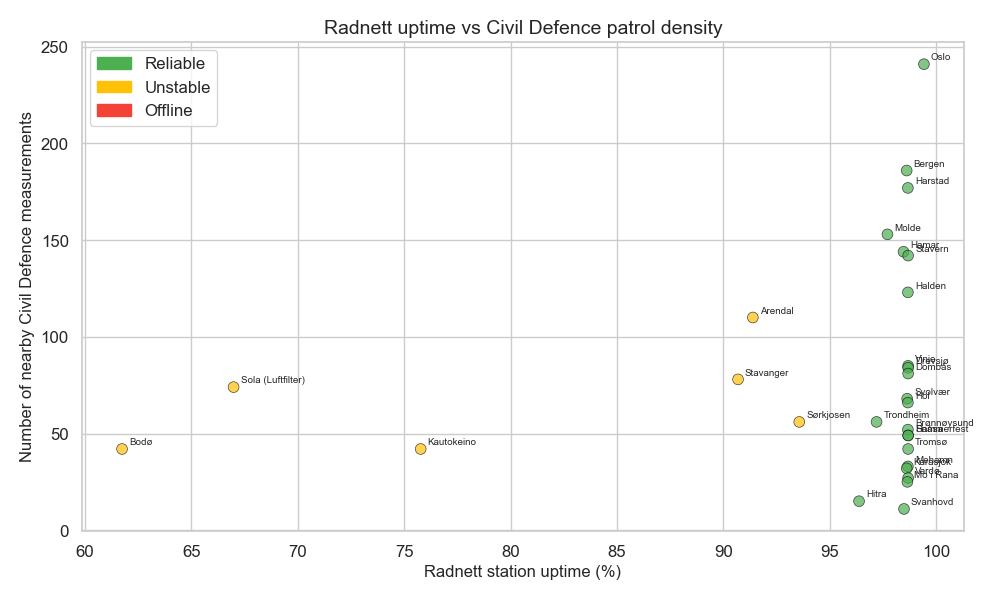

Ideally, stations with LOW uptime should have HIGH CD activity nearby.
If the pattern is the opposite, the systems overlap rather than compensate.


In [16]:
# Scatter: Radnett uptime vs nearby CD patrol density
station_summary = pd.DataFrame({
    "cd_count": station_cd_counts,
    "uptime": {s: uptime.get(s, 0) for s in station_cd_counts.index},
}).dropna()

fig, ax = plt.subplots(figsize=(10, 6))
colors = [UPTIME_COLORS.get(classify_uptime(u), "#999") for u in station_summary["uptime"]]
ax.scatter(station_summary["uptime"] * 100, station_summary["cd_count"],
           s=60, alpha=0.7, c=colors, edgecolors="black", linewidth=0.5)

for name, row in station_summary.iterrows():
    ax.annotate(name, (row["uptime"]*100, row["cd_count"]),
               textcoords="offset points", xytext=(5, 3), fontsize=7)

ax.set_xlabel("Radnett station uptime (%)")
ax.set_ylabel("Number of nearby Civil Defence measurements")
ax.set_title("Radnett uptime vs Civil Defence patrol density")

ax.legend(handles=[
    Patch(color="#4CAF50", label="Reliable"),
    Patch(color="#FFC107", label="Unstable"),
    Patch(color="#F44336", label="Offline"),
])

plt.tight_layout()
save_figure(fig, "uptime_vs_cd_density")
plt.show()

print("Ideally, stations with LOW uptime should have HIGH CD activity nearby.")
print("If the pattern is the opposite, the systems overlap rather than compensate.")

## Key Findings

*Fill in after running:*

1. How many operative stations provide 100km coverage of mainland Norway?
2. What percentage of Civil Defence measurements are within 100km of a Radnett station?
3. Are there true coverage gaps, or are the distant points coordinate errors?
4. Do Civil Defence patrols complement or overlap with Radnett?
5. Additional coordinate errors found through spatial analysis?

## Take-Home Message

*One sentence for DSA.*

## Acceptance Criteria

- [ ] Map of mainland Norway with stations colored by uptime
- [ ] Coverage buffers shown (~100km)
- [ ] Civil Defence points overlaid on combined map
- [ ] Distance distribution histogram + cumulative curve
- [ ] Furthest points listed and checked for coordinate errors
- [ ] Complementarity analysis (do patrols fill gaps?)
- [ ] Uptime vs CD density scatter
- [ ] Svalbard shown separately